# 03 - Verification escape channels

**Question this notebook answers.** A client that cannot trust a server's response must find some observation whose value depends on what the write actually did. What structural escapes exist in real servers, and how common is each?

**Reads.** `data/processed/escape_partition.json`

Run top to bottom. Every number below is computed from the raw file named above; nothing is hard-coded.

In [1]:
import json, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "notebooks"))
sys.path.insert(0, str(ROOT / "src"))
import matplotlib.pyplot as plt
import nbstyle
from nbstyle import BLUE, ORANGE, AQUA, ORDINAL, INK, INK_2, MUTED, CRITICAL
nbstyle.use_style()
PROC = ROOT / "data" / "processed"
RESULTS = ROOT / "results"

def load(name):
    p = PROC / name
    if not p.exists():
        raise FileNotFoundError(
            f"{p} is missing. Raw traces are gitignored; regenerate with the "
            f"command in results/README.md.")
    return json.loads(p.read_text(encoding="utf-8"))

print("reading from", PROC)

reading from F:\UIU\12th\CS\Paper work\repo\data\processed


Three escapes are possible:

- **ENUM** -- a collection reader taking no key. Diff it across the write.
- **SNAP** -- a reader addressable by the same identifier the write accepts.
- **CONS** -- a numeric quantity a write moves and a reader reports.

A server with none of them cannot be checked client-side at any budget.

In [2]:
from collections import Counter
part = load("escape_partition.json")
groups = Counter(r["group"] for r in part)
n = len(part)
for k, v in groups.most_common():
    print(f"{k:<18} {v:>5}  {100*v/n:>5.1f}%")

has = Counter()
for r in part:
    for e in r["escapes"]:
        has[e] += 1
print()
for k in ("ENUM","SNAP","CONS"):
    print(f"servers offering {k:<5} {has[k]:>5}  {100*has[k]/n:>5.1f}%")
none = groups.get("NONE", 0)
print(f"servers offering NONE  {none:>5}  {100*none/n:>5.1f}%")

ENUM                 558   45.9%
NONE                 308   25.3%
ENUM+SNAP            258   21.2%
SNAP                  47    3.9%
CONS+ENUM+SNAP        26    2.1%
CONS+ENUM             17    1.4%
CONS                   2    0.2%

servers offering ENUM    859   70.6%
servers offering SNAP    331   27.2%
servers offering CONS     45    3.7%
servers offering NONE    308   25.3%


saved results/figures/escape_partition.png


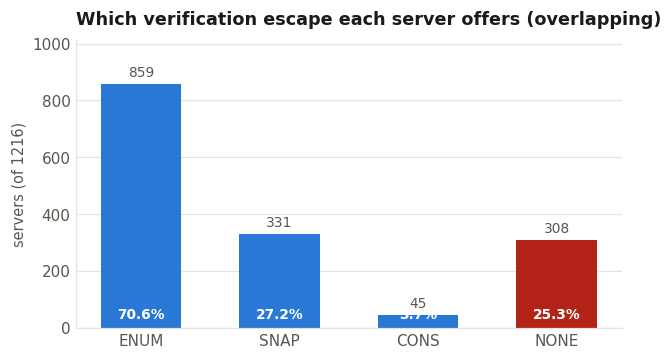

In [3]:
cats = ["ENUM", "SNAP", "CONS", "NONE"]
vals = [has["ENUM"], has["SNAP"], has["CONS"], none]
# One series; NONE is the structural floor and carries the status colour.
colors = [BLUE, BLUE, BLUE, CRITICAL]

fig, ax = plt.subplots(figsize=(6.4, 3.4))
bars = ax.bar(cats, vals, color=colors, width=0.58)
nbstyle.bar_labels(ax, bars, fmt="{:,.0f}")
for b, v in zip(bars, vals):
    ax.annotate(f"{100*v/n:.1f}%", (b.get_x()+b.get_width()/2, 0),
                xytext=(0, 6), textcoords="offset points",
                ha="center", fontsize=9, color="white", weight="bold")
ax.set_ylabel(f"servers (of {n})")
ax.set_title("Which verification escape each server offers (overlapping)")
ax.set_ylim(0, max(vals)*1.18)
nbstyle.save(fig, "escape_partition", RESULTS); plt.show()

ENUM is the most common escape. The auditor at this point implemented SNAP well and ENUM not at all, which notebook 05 tests directly.